In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime
import pickle
import seaborn as sns
from pathlib import Path
import sklearn as sk
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression

In [2]:
df = pd.read_csv("2025_DS2_HW1_data_train.csv")
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32647 entries, 0 to 32646
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            32647 non-null  object 
 1   no_of_adults                          28231 non-null  float64
 2   no_of_children                        5043 non-null   float64
 3   no_of_weekend_nights                  7729 non-null   float64
 4   no_of_week_nights                     24287 non-null  float64
 5   type_of_meal_plan                     16544 non-null  object 
 6   required_car_parking_space            17863 non-null  float64
 7   room_type_reserved                    11360 non-null  object 
 8   lead_time                             6935 non-null   float64
 9   arrival_year                          29654 non-null  float64
 10  arrival_month                         31740 non-null  float64
 11  arrival_date   

We see that we have 15 variables with "float64" data types and 4 with "object" data types.

In [6]:
missing_counts = df.isnull().sum()
info_summary = pd.DataFrame({
    'Percentage Missing': (df.isnull().sum() / len(df)) * 100
})

print(missing_counts)
print(info_summary)

Booking_ID                                  0
no_of_adults                             4416
no_of_children                          27604
no_of_weekend_nights                    24918
no_of_week_nights                        8360
type_of_meal_plan                       16103
required_car_parking_space              14784
room_type_reserved                      21287
lead_time                               25712
arrival_year                             2993
arrival_month                             907
arrival_date                            27190
market_segment_type                     14121
repeated_guest                          24978
no_of_previous_cancellations               69
no_of_previous_bookings_not_canceled    14621
avg_price_per_room                      23589
no_of_special_requests                   7450
booking_status                            352
dtype: int64
                                      Percentage Missing
Booking_ID                                      0.000000

We printed out list of numbers of missing values as well as the percentage of missing values in the category.


In [7]:
summary = df.describe()
print(summary)

       no_of_adults  no_of_children  no_of_weekend_nights  no_of_week_nights  \
count  28231.000000     5043.000000           7729.000000       24287.000000   
mean       1.845312        0.103510              0.807737           2.204966   
std        0.516860        0.407673              0.873931           1.411324   
min        0.000000        0.000000              0.000000           0.000000   
25%        2.000000        0.000000              0.000000           1.000000   
50%        2.000000        0.000000              1.000000           2.000000   
75%        2.000000        0.000000              2.000000           3.000000   
max        4.000000        9.000000              7.000000          17.000000   

       required_car_parking_space    lead_time  arrival_year  arrival_month  \
count                17863.000000  6935.000000  29654.000000   31740.000000   
mean                     0.033645    86.213266   2017.820092       7.419817   
std                      0.180319    85.92

We print our descriptive statistics.

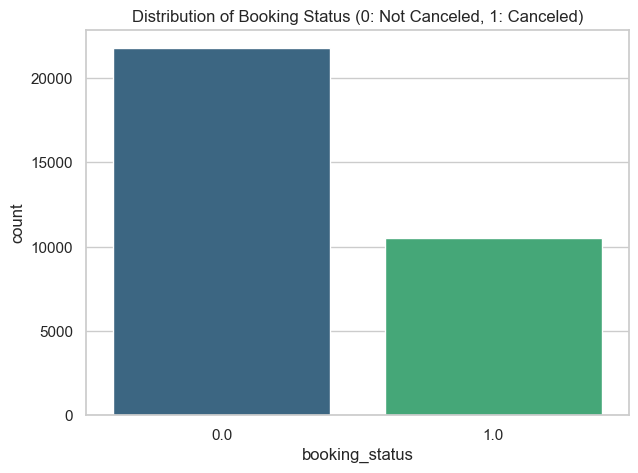

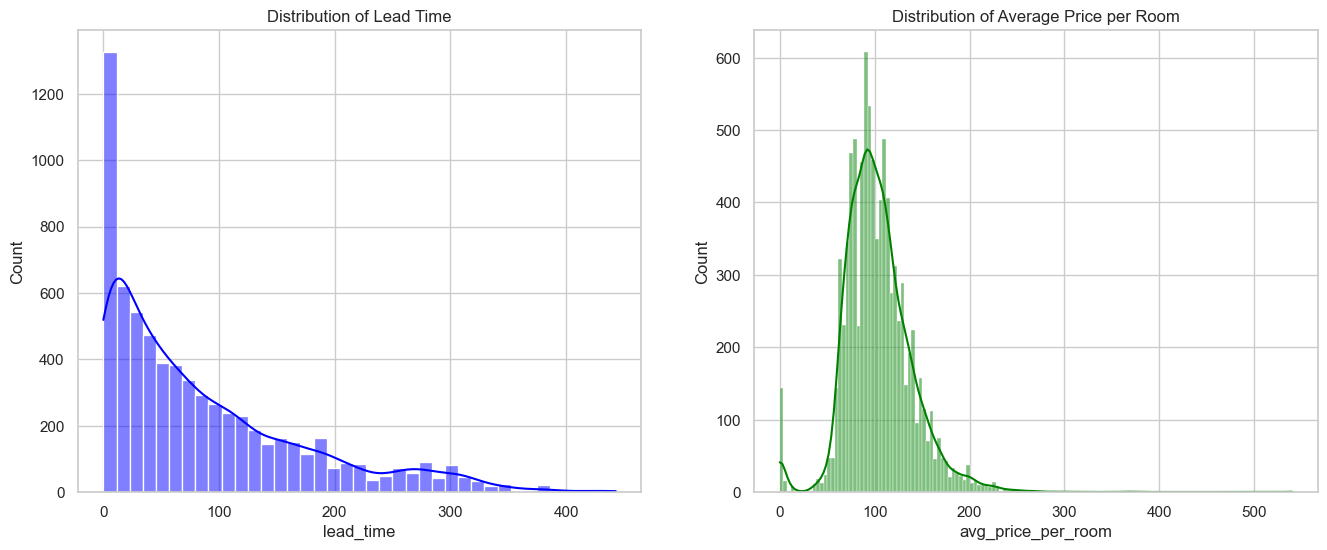

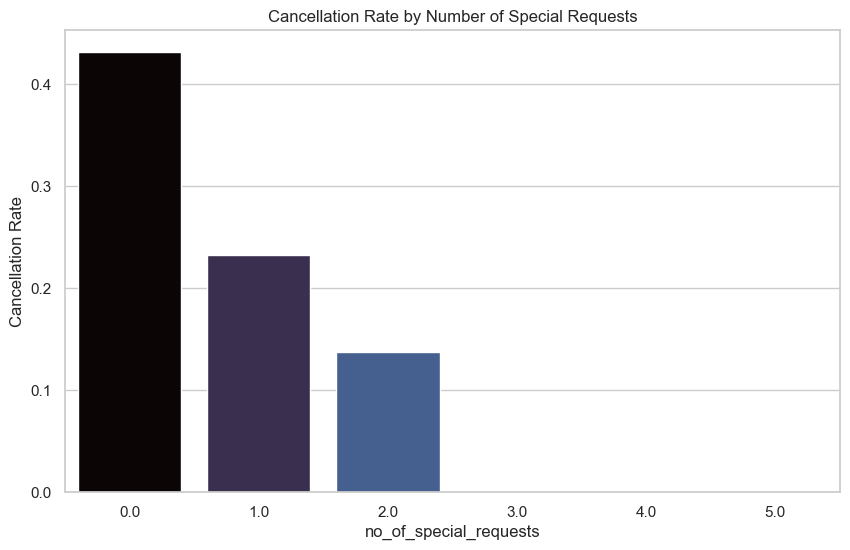

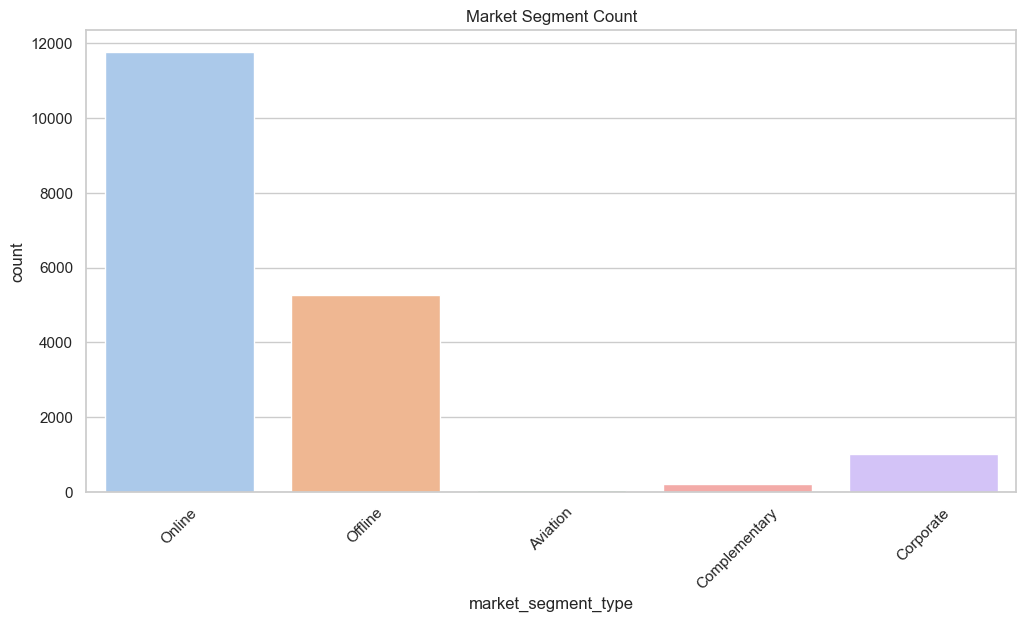

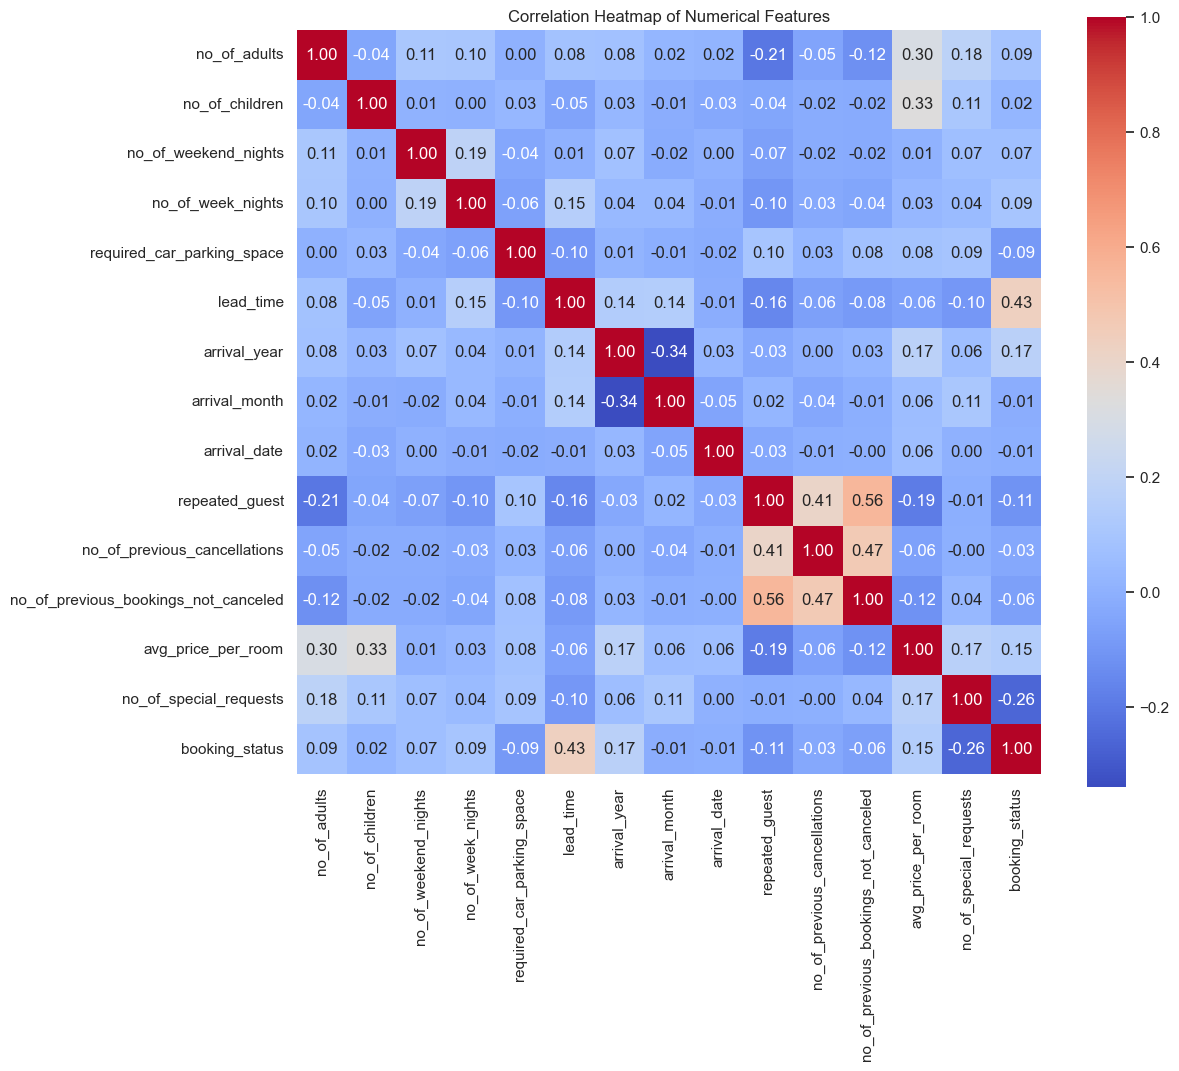

In [16]:
# We drop rows where booking_status is NaN for visualization purposes
df_clean = df.dropna(subset=['booking_status'])

# A. Target Variable Distribution
plt.figure(figsize=(7, 5))
# Fix: Assigned 'booking_status' to both x and hue, then set legend=False
sns.countplot(
    data=df_clean,
    x='booking_status',
    hue='booking_status',
    legend=False,
    palette='viridis'
)
plt.title('Distribution of Booking Status (0: Not Canceled, 1: Canceled)')
plt.show()
# B. Distributions of Key Features
# Lead Time and Average Price are usually strong predictors
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(df_clean['lead_time'].dropna(), kde=True, ax=axes[0], color='blue')
axes[0].set_title('Distribution of Lead Time')

sns.histplot(df_clean['avg_price_per_room'].dropna(), kde=True, ax=axes[1], color='green')
axes[1].set_title('Distribution of Average Price per Room')
plt.show()

# C. Relationships with the Target Variable

# Special Requests vs. Status
# Fix: Replaced 'ci' with 'errorbar' and assigned 'x' to 'hue'
plt.figure(figsize=(10, 6))
sns.barplot(
    x='no_of_special_requests',
    y='booking_status',
    data=df_clean,
    errorbar=None,
    hue='no_of_special_requests',
    legend=False,
    palette='mako'
)
plt.ylabel('Cancellation Rate')
plt.title('Cancellation Rate by Number of Special Requests')
plt.show()

# Market Segment vs. Status
# Fix: Assigned 'x' to 'hue' to satisfy the new requirement
plt.figure(figsize=(12, 6))
sns.countplot(
    x='market_segment_type',
    hue='market_segment_type',
    data=df_clean,
    palette='pastel',
    legend=False
)
# Note: If you want to see the breakdown of cancellation WITHIN the segment:
# sns.countplot(x='market_segment_type', hue='booking_status', data=df_clean, palette='pastel')

plt.title('Market Segment Count')
plt.xticks(rotation=45)
plt.show()
# D. Correlation Heatmap
plt.figure(figsize=(12, 10))
# Calculate correlation for numerical columns only
corr = df_clean.select_dtypes(include=['float64', 'int64']).corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

C:\Users\duyle\AppData\Local\Temp\ipykernel_22576\61797851.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='booking_status', y=col, palette='Set2')
C:\Users\duyle\AppData\Local\Temp\ipykernel_22576\61797851.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='booking_status', y=col, palette='Set2')
C:\Users\duyle\AppData\Local\Temp\ipykernel_22576\61797851.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='booking_status', y=col, palette='Set2')
C:\Users\duyle\AppData\Local\Temp\ipykernel_22576\61797851

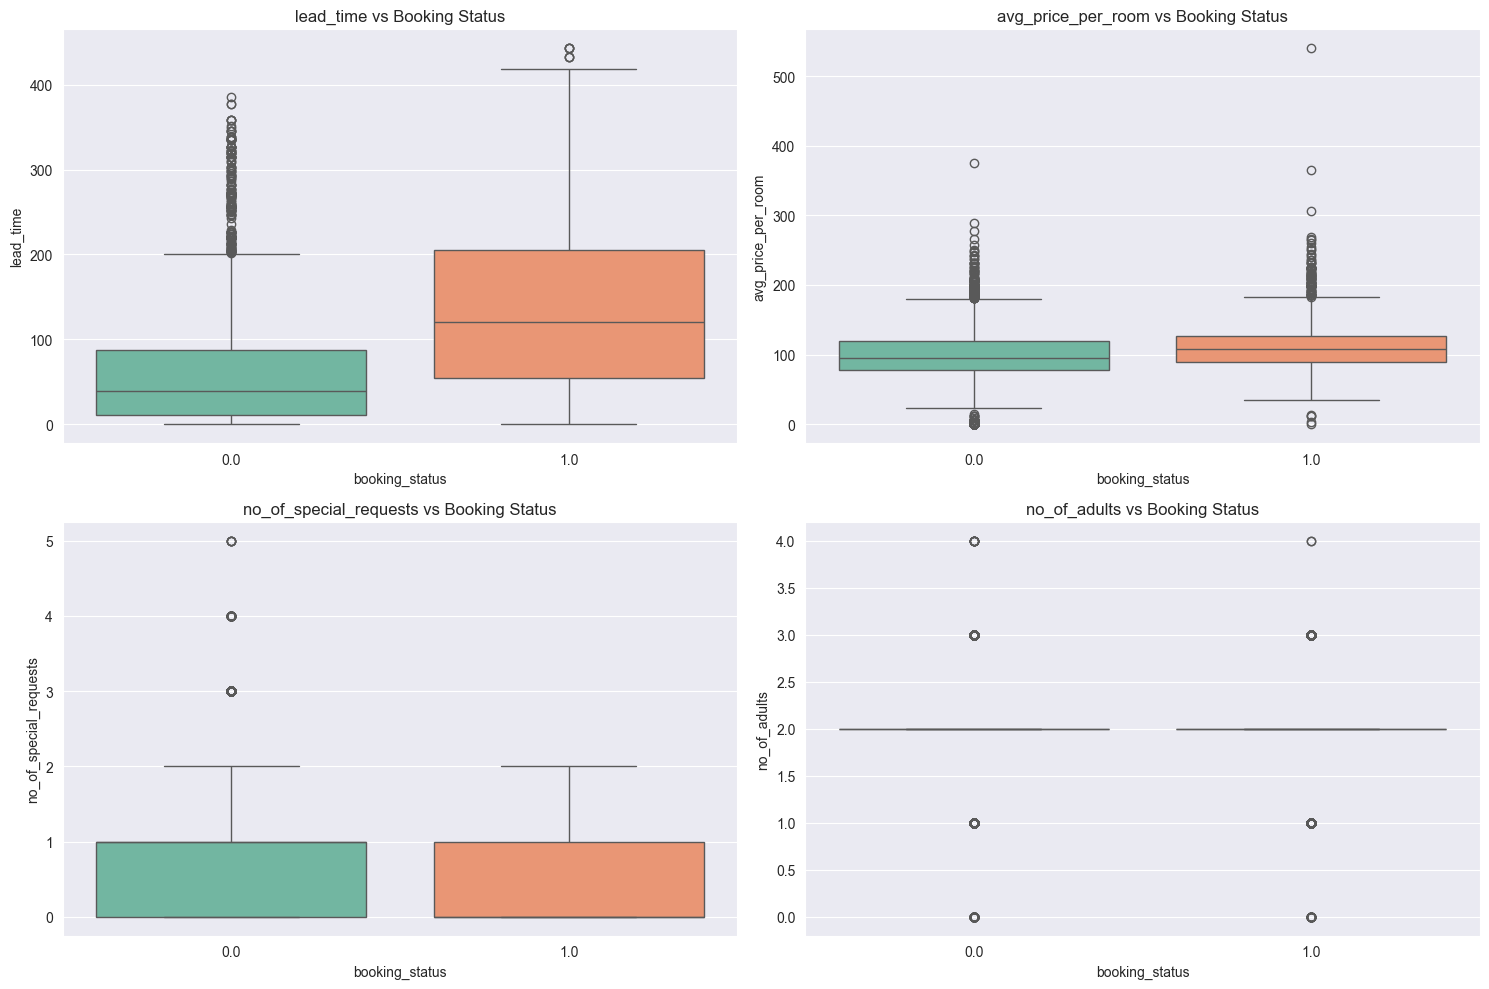

In [10]:
num_cols = ['lead_time', 'avg_price_per_room', 'no_of_special_requests', 'no_of_adults']
plt.figure(figsize=(15, 10))

for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 2, i)
    # Using a boxplot to see distribution across target classes
    sns.boxplot(data=df, x='booking_status', y=col, palette='Set2')
    plt.title(f'{col} vs Booking Status')
plt.tight_layout()
plt.show()